# Tile Generation with Gurobi

The Still Lifes generated with this software consist of what we will call "Tiles". These Tiles can be interpreted as pixels in the image, and are created using particular static patterns in Conway's Game of Life. In this Notebook, we show step by step how these patterns arise. In short: the Mosaic consists of Tiles, the Tiles are created from Ponds.

## Overview

The Tiles used in Game of Life Mosaics are stable patterns in Conway's Game of Life that don't change over time. We generate these patterns with specific properties:

1. **8-fold symmetry**: Patterns are symmetric under all rotations and reflections
2. **Stable**: Each living cell has exactly 2 or 3 living neighbors; each dead cell cannot have exactly 3 living neighbours.

In order to actually find these patterns, we use **Integer Linear Programming (ILP)** with Gurobi. Refer to the method `_find_all_symmetric_gol_mosaics` in the `PatternLibrary` class for details, or to the 2019 book "Opt Art" by Robert Bosch (ISBN 0-691-19703-2).

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Import gol_mosaics (installed with: pip install -e .)
from gol_mosaics import PatternLibrary

# Enable LaTeX and set Times New Roman as the font
from matplotlib import rcParams
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "figure.dpi": 100,
    "savefig.dpi": 1200,
})

# Note: This notebook requires a Gurobi license
# Academic licenses are free: https://www.gurobi.com/academia/
try:
    import gurobipy as gp
    from gurobipy import GRB
    print("✓ Gurobi is installed")
except ImportError:
    print("✗ Gurobi not found. Install with: pip install gurobipy")
    print("  (Requires license - free for academics)")

%load_ext autoreload
%autoreload 2

✓ Gurobi is installed
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Step 1: Example of Still Life tiles

In Conway's Game of Life, a Still Life is a pattern where every living cell has exactly 2 or 3 living neighbours, and every dead cell has 0, 1, 2, 4, 5, 6, 7, or 8 living neighbours (anything except 3).

Before getting to the technicalities of how these patterns are created, let's visualise some example elementary Still Lifes for different densities and detail levels. We will refer to these elementary Still Lifes as "tiles".

Level 5 patterns: 2632 patterns
Pattern size: (30, 30)
Density range: 0.000 to 1.000


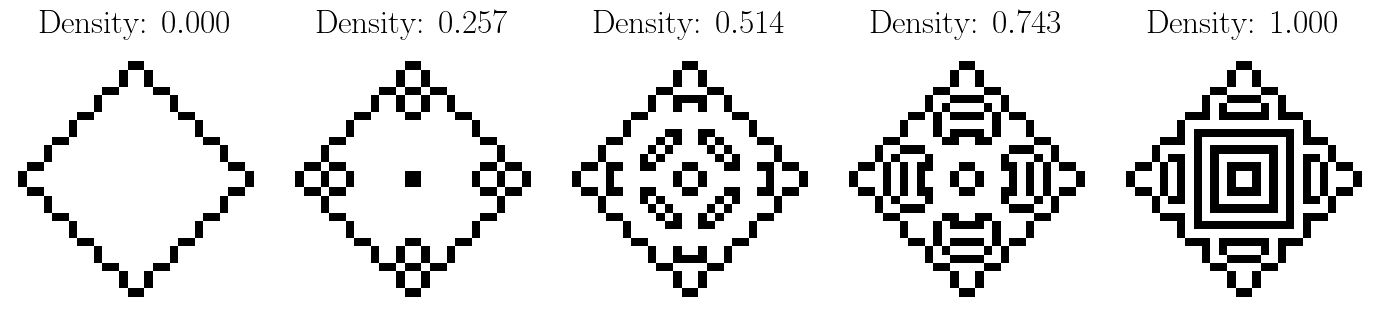

In [17]:
# Load pre-computed patterns
level=5
library = PatternLibrary.load(level=level)

print(f"Level {level} patterns: {len(library.solutions)} patterns")
print(f"Pattern size: {library.solutions.shape[1:]}")
print(f"Density range: {library.densities.min():.3f} to {library.densities.max():.3f}")

# Show patterns at different densities
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
fontsize = 24
densities_to_show = [0.0, 0.25, 0.5, 0.75, 1.0]

for ax, target_density in zip(axes, densities_to_show):
    # Find pattern closest to target density
    idx = np.argmin(np.abs(library.densities - target_density))
    pattern = library.solutions[idx]
    actual_density = library.densities[idx]
    
    ax.imshow(pattern, cmap='binary', interpolation='nearest')
    ax.set_title(fr'Density: ${{{actual_density:.3f}}}$', fontsize=fontsize, y=1.05)
    ax.axis('off')

# plt.suptitle(f'Tile patterns for level {level} at different densities', fontsize=fontsize+2, y=1.05)
plt.tight_layout()

plt.savefig(f'gol_mosaics_level_{level}_patterns.pdf', bbox_inches='tight')

plt.show()

Note that these are five different tiles that are all 8-fold symmetric and static according to the rule of the Game of Life. Additionally, they all have different densities. The tile with the lowest number of living cells, on the left, is said to have density 0. The tile with the highest number of living cells, on the right, is said to have density 1.

## Step 2: Elementary - the Pond pattern

The atomic unit of our Still Lifes is a simple pattern consisting of 8 living cells, which in the Game of Life literature known as the Pond pattern. Pond patterns can be tied together to create larger patterns that remain static.

Concretely, we can:
1. Use the Pond pattern as-is: dimensions 6×6 (including the border of dead cells), level 1
2. Tile multiple ponds together into a diamond shape: dimensions (6x6)*level
3. Extract just the edge/border

The border defines the outline of our Tile, and this empty Tile can be filled in numerous ways.

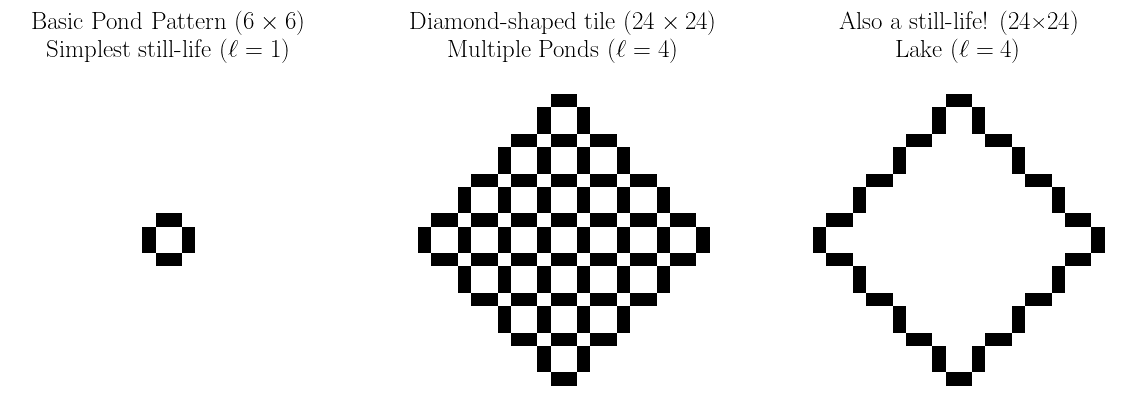

In [32]:
# Show how the pattens are built up
# Use the library from Step 1, or create an instance for pond patterns
level = 4
library = PatternLibrary.load(level=level)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fontsize=18
title_offset = 1.05

# 0. get pond_multiple object for dimensions
pond_multiple = library.pond_pattern_multiple()
height, width = pond_multiple.shape

# 1. Basic pond pattern (6x6)
basic_pond = PatternLibrary.pond_pattern()
basic_pond_show = np.zeros_like(pond_multiple)
basic_pond_show[3*level-2:3*level+2,3*level-2:3*level+2] = basic_pond
axes[0].imshow(basic_pond_show, cmap='binary', interpolation='nearest')
axes[0].set_title(f'Basic Pond Pattern ($6 \\times 6$)\nSimplest still-life ($\\ell = 1$)', fontsize=fontsize, y=title_offset)
axes[0].axis('off')
axes[0].set_xticks(np.arange(-0.5, 4, 1), minor=True)
axes[0].set_yticks(np.arange(-0.5, 4, 1), minor=True)
axes[0].grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

# 2. Multiple ponds glued together
axes[1].imshow(pond_multiple, cmap='binary', interpolation='nearest')
axes[1].set_title(f'Diamond-shaped tile (${height}\\times{width}$)\nMultiple Ponds ($\\ell = {level}$)', fontsize=fontsize, y=title_offset)
axes[1].axis('off')

# 3. Edge pattern only
pond_edge = library.pond_pattern_edge()
axes[2].imshow(pond_edge, cmap='binary', interpolation='nearest')
axes[2].set_title(f'Also a still-life! ({height}×{width})\nLake ($\\ell = {level}$)', fontsize=fontsize, y=title_offset)
axes[2].axis('off')

# plt.suptitle('Pond Pattern Evolution', fontsize=14, y=1.02)
plt.tight_layout()

plt.savefig(f'gol_mosaics_level_{level}_pond_and_lake.pdf', bbox_inches='tight')

plt.show()

## Step 3: 8-Fold Symmetry

To create mosaics with a diamond/diagonal layout, we need patterns with 8-fold symmetry:
- 4 rotational symmetries (90°, 180°, 270°, 360°)
- 4 reflection symmetries (horizontal, vertical, 2 diagonals)

This means we only need to solve for 1/8 of the pattern - the rest is determined by symmetry!

_Note_: in group theory, this is called the dihedral group $D_4$.

Let's visualize this:

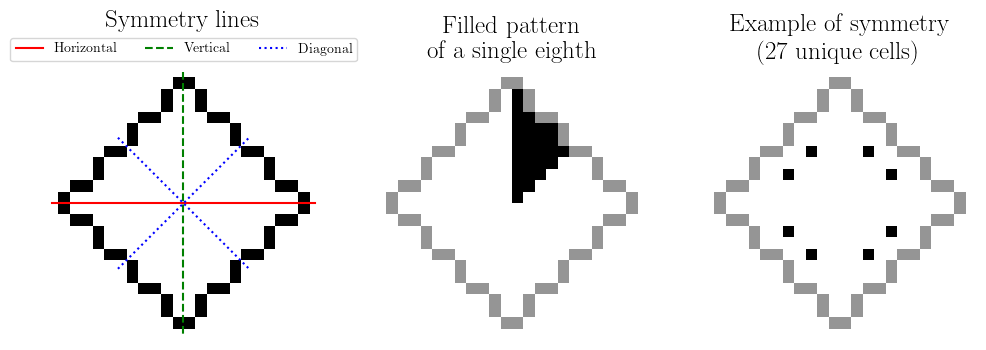

In [42]:
# TODO: this visualisation only works for level 4

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
fontsize = 18

axs[0].imshow(pond_edge, cmap='Greys')

### first figure: symmetry lines
axs[0].plot([0, height-1], [.5*(height-1), .5*(height-1)], color='red', label='Horizontal', ls='-')
axs[0].plot([.5*(height-1), .5*(height-1)], [0, height-1], color='green', label='Vertical', ls='--')
axs[0].plot([.25*(height-1), .75*(height-1)], [.25*(height-1), .75*(height-1)], color='blue', label='Diagonal', ls=':')
axs[0].plot([.25*(height-1), .75*(height-1)], [.75*(height-1), .25*(height-1)], color='blue', ls=':')

axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3)

### second figure: filled pattern of a single eigth
pond_edge_eighth = library.pond_pattern_eighth()
number_unique_cells = np.sum(pond_edge_eighth)
eighth_show = pond_edge + 2*pond_edge_eighth

axs[1].imshow(eighth_show, cmap='Greys')

### third figure: example of symmetry
pond_edge_single = pond_edge.copy()
# test value
(i,j) = height//3+1, height//3-1
pond_edge_single[i,j] = 2

# add all symmetries
pond_edge_single[width-i-1, j] = 2  # vertical symmetry
pond_edge_single[i, width-j-1] = 2  # horizontal symmetry
pond_edge_single[width-i-1, width-j-1] = 2  # vertical and horizontal symmetry
pond_edge_single[j, i] = 2  # diagonal symmetry
pond_edge_single[j, width-1-i] = 2 # diagonal and vertical symmetry
pond_edge_single[width-1-j, i] = 2  # diagonal and horizontal symmetry
pond_edge_single[width-1-j, width-1-i] = 2  # all symmetries

axs[2].imshow(pond_edge_single, cmap='Greys')

axs[0].set_title('Symmetry lines\n', fontsize=fontsize, y=1.02)
axs[1].set_title('Filled pattern\nof a single eighth', fontsize=fontsize)
axs[2].set_title(f'Example of symmetry\n({number_unique_cells} unique cells)', fontsize=fontsize)

for ax in axs:
    ax.axis('off')

# plt.savefig(f'gol_mosaics_level_{level}_symmetry_explanation.pdf', bbox_inches='tight')

## Step 4: Generating Multiple Patterns

To create a useful library for mosaics, we need patterns at many different density levels.

The `PatternLibrary.generate()` class method uses Gurobi to find all possible still-life patterns for a given level.

Generating patterns of level 1 ...
Looking for pattern level 1 with grid size 6x6
Found 1 optimal solutions.

✓ Generated 1 unique patterns
Normalised density range (by definition): 1.000 to 1.000


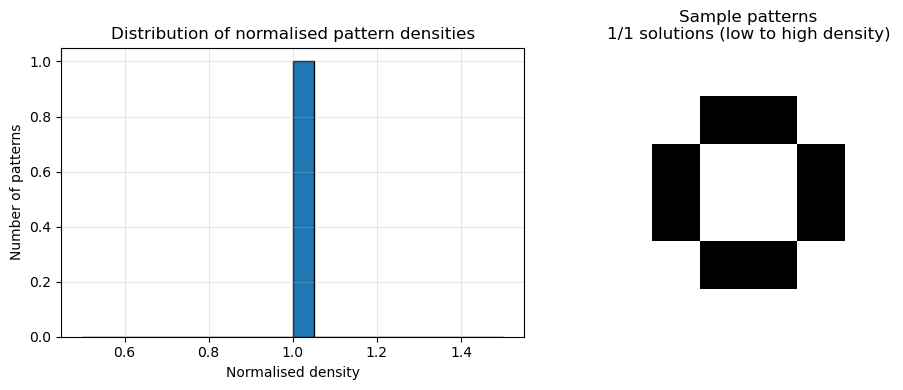

In [23]:
level=1
solution_limit = 100

# Generate patterns for desired level
print(f"Generating patterns of level {level} ...")
if level == 4:
    print("This may take a few seconds ...")
elif level == 5:
    print("This may take a few minutes ...")
    print(f"(and we'll stop searching after {solution_limit} solutions)\n")

# Use the public API to generate patterns
library = PatternLibrary.generate(level=level, solution_limit=solution_limit)

print(f"\n✓ Generated {len(library.solutions)} unique patterns")

# Calculate densities
densities = library.densities
print(f"Normalised density range (by definition): {densities.min():.3f} to {densities.max():.3f}")

# Visualize density distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(densities, bins=20, edgecolor='black')
plt.xlabel('Normalised density')
plt.ylabel('Number of patterns')
plt.title('Distribution of normalised pattern densities')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
# Show sample of patterns
n_samples = min(10, len(library.solutions))
indices = np.linspace(0, len(library.solutions)-1, n_samples, dtype=int)
combined = np.hstack([library.solutions[i] for i in indices[::-1]])
plt.imshow(combined, cmap='binary', interpolation='nearest')
plt.title(f'Sample patterns\n{n_samples}/{len(library.solutions)} solutions (low to high density)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Step 5: Verifying Still-Life Property

Let's verify that our generated patterns are indeed valid still-lifes by simulating them in Game of Life.

We simply take a random pattern and evolve it over a single timestep.

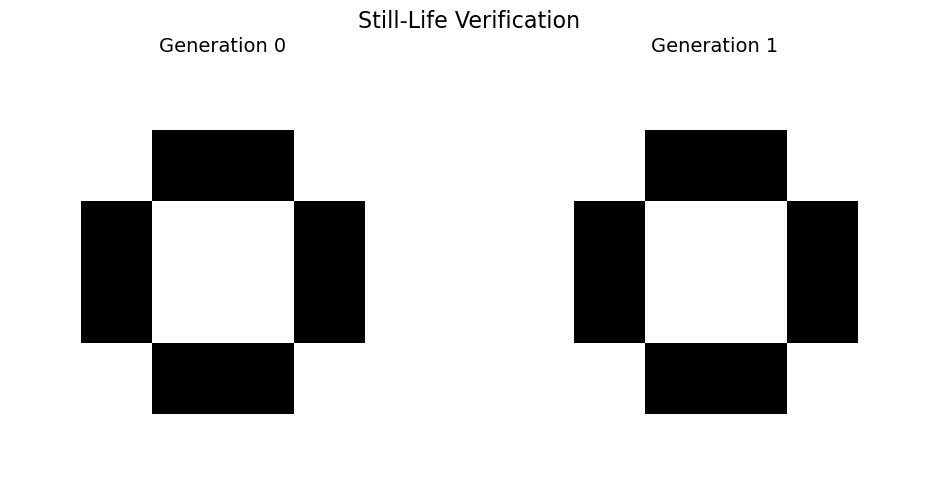

✓ Pattern is a valid still-life (unchanged after 1 generation)


In [24]:
def step_game_of_life(grid):
    """Advance Game of Life by one generation."""
    N = len(grid)
    new_grid = np.zeros_like(grid)
    
    for i in range(N):
        for j in range(N):
            # Count neighbors
            neighbors = 0
            for di in [-1, 0, 1]:
                for dj in [-1, 0, 1]:
                    if di == 0 and dj == 0:
                        continue
                    ni, nj = i + di, j + dj
                    if 0 <= ni < N and 0 <= nj < N:
                        neighbors += grid[ni, nj]
            
            # Apply rules
            if grid[i, j] == 1:  # Cell is alive
                new_grid[i, j] = 1 if neighbors in [2, 3] else 0
            else:  # Cell is dead
                new_grid[i, j] = 1 if neighbors == 3 else 0
    
    return new_grid

# Test a generated pattern
test_pattern = library.solutions[np.random.randint(0, len(library.solutions))]  # Pick random pattern
next_gen = step_game_of_life(test_pattern)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(test_pattern, cmap='binary', interpolation='nearest')
axes[0].set_title('Generation 0', fontsize=14)
axes[0].axis('off')

axes[1].imshow(next_gen, cmap='binary', interpolation='nearest')
axes[1].set_title('Generation 1', fontsize=14)
axes[1].axis('off')

plt.suptitle('Still-Life Verification', fontsize=16)
plt.tight_layout()
plt.show()

if np.array_equal(test_pattern, next_gen):
    print("✓ Pattern is a valid still-life (unchanged after 1 generation)")
else:
    print("✗ Pattern changed - not a still-life!")
    print(f"  Differences: {np.sum(test_pattern != next_gen)} cells")

## Step 6: Comparing Pattern Levels

Different levels produce patterns of different sizes and more pattern possibilities:

- **Level 1**: 6x6 tiles (1 patter)
- **Level 2**: 12x12 tiles (2 patterns)
- **Level 3**: 18×18 tiles (7 patterns)
- **Level 4**: 24×24 tiles (85 patterns)  
- **Level 5**: 30×30 tiles (2632 patterns)

Notice how higher levels can achieve
- More intricate details
- Better density precision
- More varied structures

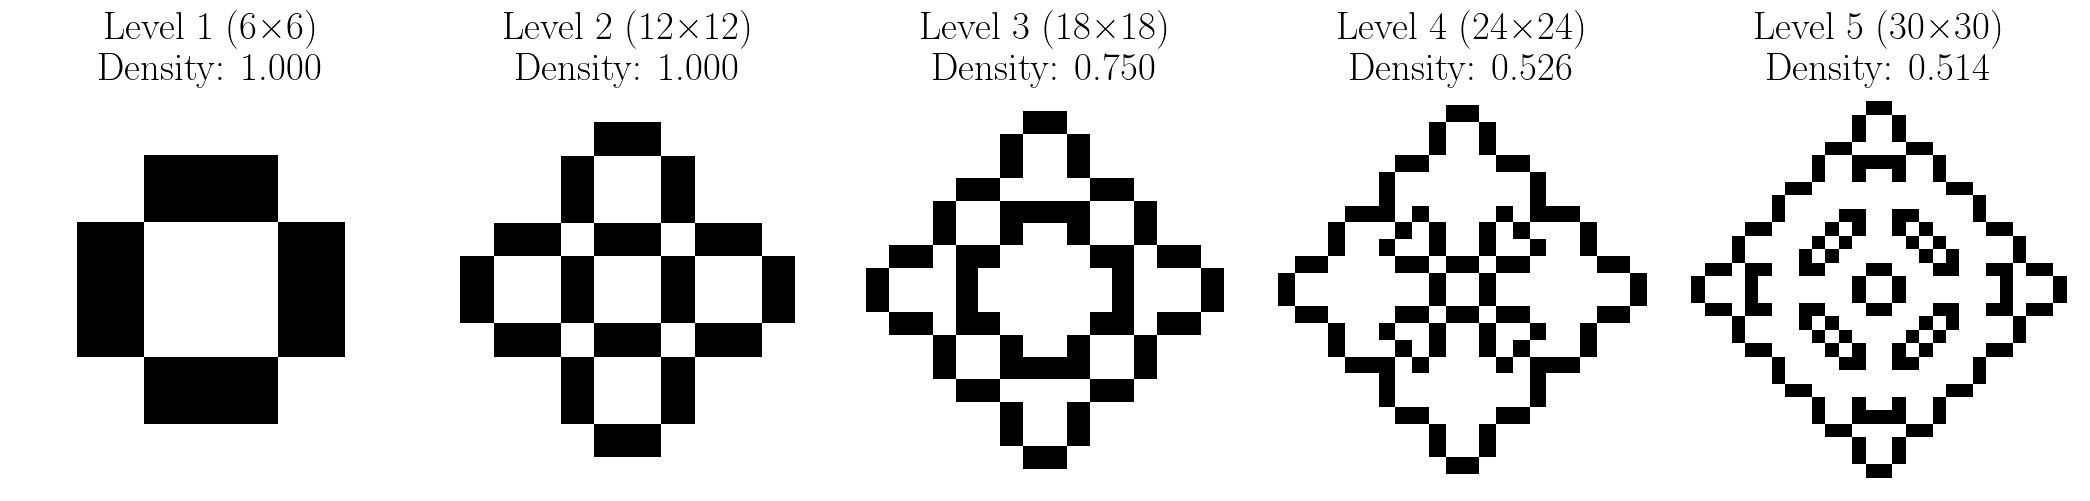

In [62]:
# Compare different levels
fig, axes = plt.subplots(1, 5, figsize=(21, 5))
fontsize=28

levels = [1, 2, 3, 4, 5]
target_density = 0.5

for ax, level in zip(axes, levels):
    library = PatternLibrary.load(level=level)
    
    # Find pattern closest to target density
    idx = np.argmin(np.abs(library.densities - target_density))
    pattern = library.solutions[idx]
    actual_density = library.densities[idx]
    
    size = 6*level
    ax.imshow(pattern, cmap='binary', interpolation='nearest')
    ax.set_title(f'Level {level} ({size}×{size})\nDensity: {actual_density:.3f}', fontsize=fontsize)
    ax.axis('off')

# plt.suptitle('Pattern Complexity at Different Levels', fontsize=fontsize+2, y=1.03)
plt.tight_layout()

plt.savefig('gol_mosaics_pattern_complexity_comparison.pdf', bbox_inches='tight')

plt.show()

These tiles are the building blocks of the mosaics we will be creating.